# 01 · Introduction

QProgram is a Python library for writing pulse programs: the timed control signals that a circuit-level gate turns into on real hardware. This notebook is the tour of the language. You will build a program, read the operations it is made of, name the lines they run on, look at the pulse shapes they play, write the whole thing to a file, read it back, and run it on the software platform that ships inside the library.

Three notebooks carry the material. This one is the vocabulary. **Basics** adds the loops that turn a single sequence into an experiment, and the labeled arrays that come back from one. **Advanced** is a set of independent sections on extending the language and on describing the machine that runs it.

Nothing here talks to hardware. QProgram ships a pure-Python reference platform, so every cell in all three notebooks runs on a laptop with no instrument, no cloud account, and no driver installed.

## Before you start

Run the next two cells. The first installs QProgram when it is missing, as a fresh Google Colab runtime needs and a local install has already done. The second prints the two versions that matter. QProgram needs Python 3.11 or newer, and versions through 3.14 are tested.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0"], check=True)
    import qprogram  # noqa: F401

In [2]:
import sys
from importlib.metadata import version

print("python  ", ".".join(str(v) for v in sys.version_info[:3]), "(3.11 to 3.14 are tested)")
print("qprogram", version("qprogram"))

python   3.14.7 (3.11 to 3.14 are tested)
qprogram 0.1.0


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusNaming, BusSchema
from qprogram.waveforms import Arbitrary, FlatTop, Gaussian, IQDrag, IQPair
from qprogram.waveforms import IQZero, Ramp, Square, SuddenNetZero

## 1.1 Three numbers

A pulse program is arithmetic on numbers a fridge gave you, so the three this notebook needs are declared once here.

`F01` is the qubit transition frequency, the energy gap between the two levels used as 0 and 1 divided by Planck's constant. A tone at that frequency rotates the qubit between them, and a tone anywhere else mostly does not. `F_READOUT` is the frequency of the readout resonator, a small microwave cavity coupled to the qubit. A transmon is never measured directly, so a tone goes past the resonator instead and what comes back carries the qubit state. `A_PI` is the drive amplitude that takes 0 all the way to 1, in the dimensionless units a DAC accepts.

On a real chip all three are measured rather than looked up, and measuring them is a day of work. Here they are three constants, so the code stays about the language.

In [4]:
F01 = 4.85e9  # Hz, the qubit 0 to 1 transition
F_READOUT = 7.20e9  # Hz, the readout resonator coupled to that qubit
A_PI = 0.62  # DAC units, the drive amplitude of a full 0 to 1 rotation

print(f"drive tone   {F01 / 1e9:.2f} GHz")
print(f"readout tone {F_READOUT / 1e9:.2f} GHz")

drive tone   4.85 GHz
readout tone 7.20 GHz


## 1.2 A program is data

`qp.QProgram` is a builder. Every method you call on it appends one typed node to a tree and sends nothing anywhere, so what you hold afterwards is a value your own code can read, compare, rewrite, and save.

A bus is the line a signal goes down, and the simplest way to name one is a plain string. The three programs in this section and the next are written that way, and section 1.4 replaces the strings with something checked.

`label` names the program and `description` is a sentence for whoever reads it later. Both are optional and both ride into the file.

In [5]:
first = qp.QProgram(label="first_program", description="One drive pulse on qubit 0.")
first.set_frequency("q0/drive", F01)
first.play("q0/drive", IQDrag(amplitude=A_PI, duration=40, sigma=10, beta=0.15))

print(qp.dumps(first))

#!QProgram 1.0

metadata:
  label: "first_program"
  description: "One drive pulse on qubit 0."

body:
  set_frequency "q0/drive" 4850000000.0
  play "q0/drive" IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)



That text is the `.qp` format, and section 1.7 is where you write it to a file. Read it now as a picture of the tree: a header carrying the label and the description, then a body holding one statement per node, in the order you wrote them.

Two accessors summarise a program. `buses` walks the tree on every access, so it always reports the lines the program as it stands actually touches, and `body.elements` is the plain Python list of the body's children.

In [6]:
print("buses:  ", sorted(first.buses))
print("nodes:  ", [type(node).__name__ for node in first.body.elements])

buses:   ['q0/drive']
nodes:   ['SetFrequency', 'Play']


## 1.3 The operations

Naming a line is half the vocabulary and the verbs are the other half. Each call below appends exactly one node to whichever block is open and returns `None`, with two exceptions noted in the table.

Durations are nanoseconds, frequencies hertz, phases radians, and gain and offset are dimensionless. Every numeric argument also accepts a variable or an expression built from one, and that is the Basics notebook.

| Call | Node it appends | What it is for |
|---|---|---|
| `play(bus, waveform)` | `Play` | put one envelope on the line |
| `measure(bus, waveform, weights, *, name=None, fields=(MF.IQ,))` | `Measure` | output a readout pulse and acquire what comes back. Returns a `MeasurementHandle` |
| `wait(bus, duration)` | `Wait` | idle one bus for a number of nanoseconds |
| `sync(buses=None)` | `Sync` | hold the listed buses until the furthest ahead has finished |
| `set_frequency(bus, frequency)` | `SetFrequency` | park the carrier of a line |
| `set_phase(bus, phase)`, `reset_phase(bus)` | `SetPhase`, `ResetPhase` | write the oscillator phase, or zero it |
| `set_gain(bus, gain)` | `SetGain` | scale the whole output path of a line |
| `set_offset(bus, offset_path0, offset_path1=None)` | `SetOffset` | write a DC level, one argument per path |
| `set_parameter(bus, parameter, value)` | `SetParameter` | write a setting the platform holds as configuration |
| `get_parameter(bus, parameter)` | `GetParameter` | read one back. Returns a `Variable` the run fills in |
| `call(fragment, *args, **kwargs)` | `Call` | invoke a named sub-program. Advanced |

QProgram did not invent that vocabulary. It is close to the intersection of what commercial sequencers offer, given portable names, and the Advanced notebook adds to it through a vendor namespace rather than a patch to the core.

Five block containers hold operations. `block()` is the plain one and appears below. `average(shots)` and `sweep(variable, source)` are the loops, and they compose in lockstep with `|`, all three in Basics. `if_`, `elif_`, and `else_` branch on a measurement, in Advanced.

### A sequence, start to finish

The program below prepares the qubit and reads it out, and it uses most of the verbs you need for a day at the bench.

`set_gain` and the `amplitude` inside a waveform are two different knobs: gain scales the whole output path and the amplitude shapes the envelope. `reset_phase` zeroes the oscillator phase so that every repetition starts from the same reference, which matters as soon as the phase the qubit accumulates is the thing being measured. `with program.block():` opens a plain container and changes nothing about what the statements inside it mean, so the preparation reads as one group.

`wait` and `play` are the only two operations that book time. Instructions land on a clock grid, typically 4 ns wide, and QProgram rounds nothing onto it: a 3 ns wait reaches the platform as a 3, and the platform is where it is accepted or refused.

In [7]:
readout_pulse = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
weights = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))
pi_pulse = IQDrag(amplitude=A_PI, duration=40, sigma=10, beta=0.15)

sequence = qp.QProgram(label="prepare_and_read", description="A pi pulse on qubit 0, then a readout.")
with sequence.block():
    sequence.set_frequency("q0/drive", F01)
    sequence.set_gain("q0/drive", 1.0)
    sequence.reset_phase("q0/drive")
    sequence.play("q0/drive", pi_pulse)
    sequence.wait("q0/drive", 4)  # ns of dead time before the readout starts
sequence.set_frequency("q0/readout", F_READOUT)
sequence.sync(["q0/drive", "q0/readout"])
m0 = sequence.measure("q0/readout", readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(sequence))

#!QProgram 1.0

metadata:
  label: "prepare_and_read"
  description: "A pi pulse on qubit 0, then a readout."

body:
  block:
    set_frequency "q0/drive" 4850000000.0
    set_gain "q0/drive" 1.0
    reset_phase "q0/drive"
    play "q0/drive" IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
    wait "q0/drive" 4
  set_frequency "q0/readout" 7200000000.0
  sync "q0/drive" "q0/readout"
  measure "q0/readout" IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="m0" fields=["state", "iq"]



### The sync barrier

Every bus keeps its own cursor, advanced only by the pulses and waits written to that bus, so two lines that have played different amounts have drifted apart by exactly the difference. A circuit has one global clock and a pulse program does not, and `sync` exists for that reason.

`sync(buses)` holds every listed bus until the furthest ahead has finished. A bare `sync()` covers every bus in the program, convenient in a short sequence and expensive in a long one, and `sync([])` raises rather than guess what you meant. The distinction matters later: the Advanced notebook shows a rewrite that a bare `sync()` quietly blocks.

In [8]:
def statement(program, keyword):
    """The first statement of a program's `.qp` text that starts with `keyword`."""
    for line in qp.dumps(program).splitlines():
        if line.strip().startswith(keyword):
            return line.strip()
    return f"no {keyword} statement"


broadcast = qp.QProgram(label="broadcast_sync")
broadcast.play("q0/drive", pi_pulse)
broadcast.sync()  # every bus in the program

print("named targets:", statement(sequence, "sync"))
print("a bare sync:  ", statement(broadcast, "sync"))

try:
    broadcast.sync([])
except qp.ValidationError as exc:
    print("an empty list:", exc)

named targets: sync "q0/drive" "q0/readout"
a bare sync:   sync
an empty list: sync([]) is ambiguous; pass None (or no argument) to sync all buses


### What a measurement asks for

`measure(bus, waveform, weights)` outputs the readout pulse itself, so there is no separate `play` on a readout line. The second waveform is the integration window, which multiplies the ADC stream before it is summed into the single point you get back, and a flat window of ones is the honest default this material uses throughout.

`fields=` says which of a measurement's outputs you want. `MF.IQ` is the integrated complex point and the default, `MF.STATE` is the platform's classification of that point into a 0 or a 1, and `MF.RAW` is the ADC trace the other two are computed from. Asking for a name that is not a field raises at the call rather than at run time.

`measure` returns a `MeasurementHandle`, and a handle is a name and nothing more. The name is how you ask for this measurement's data after a run, and section 1.8 uses it for exactly that. Pass `name=` to choose one yourself, and a name already taken is refused.

In [9]:
print("fields a core measurement can ask for:", [field.value for field in MF])
print("this handle:", m0.name)

try:
    sequence.measure("q0/readout", readout_pulse, weights, fields=("iq", "bogus"))
except qp.ValidationError as exc:
    print("\nchecked at the call:", exc)

fields a core measurement can ask for: ['state', 'iq', 'raw']
this handle: m0

checked at the call: unknown measurement field(s) ['bogus']. Known fields: ['iq', 'raw', 'state']. A vendor extension adds its own by registering `measure.fields.<name>` via qprogram.protocol.register_capability_tokens.


### Settings the sequencer does not own

`set_frequency` and `set_gain` write registers a sequencer owns and can change between one pulse and the next. `set_parameter(bus, name, value)` writes something the platform holds as configuration instead, a room-temperature attenuator or a local oscillator, and a platform is free to realize it as a slow write over a chassis link. The parameter name is a free string that nothing validates, so a typo becomes a setting the platform has never heard of.

`get_parameter(bus, name)` is the read direction and the second of the two calls that hand something back. It appends the read and returns a fresh `Variable`, which the runtime fills in during the run. The `var` line at the top of the body below is that variable, declared with an id derived from the bus and the parameter. A variable is the whole subject of the Basics notebook, and this is the one place the Introduction produces one.

`set_offset` is the third way to put a level on a line, and the `.qp` text tells the three apart. `set_offset` has value slots and no duration, `set_gain` has one value slot and scales whatever is played next, and `play` is the only one of the three that puts a shape on the timeline.

In [10]:
knobs = qp.QProgram(label="settings")
knobs.set_parameter("q0/drive", "attenuation", 20.0)
attenuation = knobs.get_parameter("q0/drive", "attenuation")
knobs.set_offset("q0/flux", 0.05)

print(qp.dumps(knobs).split("body:")[1].rstrip())


  var q0_drive_attenuation label="q0/drive.attenuation"

  set_parameter "q0/drive" "attenuation" 20.0
  get_parameter "q0/drive" "attenuation" -> q0_drive_attenuation
  set_offset "q0/flux" 0.05


## 1.4 Buses and schemas

Nothing checked those bus names. Misspell `"q0/readout"` as `"q0/raedout"` and every program above still builds, still prints, and finds you out on hardware.

`BusSchema` closes that gap without changing what lands in the tree. A schema declares which kinds of bus each element of the chip has, and it declares nothing about how many of each element exist, so any index resolves. What it hands back is a `BusRef`, a real `str` subclass carrying metadata about the line, and everywhere QProgram accepts a bus name a `BusRef` works.

Two fields carry most of the value. `channel` records how many DACs feed the line, so a drive line is `IQ` and a flux line is `single`. `acquires` records whether an ADC listens to it. Both are facts about copper, and both become errors on the line that made the mistake.

In [11]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q

for bus in (q[0].drive, q[0].readout, q[0].flux):
    print(f"{bus:12} channel={bus.channel:6} acquires={bus.acquires}")

print("\nstill a string:", isinstance(q[0].drive, str), "| any index resolves:", q[7].drive)

q0/drive     channel=IQ     acquires=False
q0/readout   channel=IQ     acquires=True
q0/flux      channel=single acquires=False

still a string: True | any index resolves: q7/drive


Six schemas ship, three families each with a `_coupled` variant that adds an element `c` for the tunable couplers between qubit pairs. `BusSchema.transmon()` gives each qubit a drive line and a readout line, and `BusSchema.flux_tunable_transmon()` adds the flux line used above. When none of the six fits, `add_element` on a bare `BusSchema()` registers one at run time.

In [12]:
for name in ("transmon", "flux_tunable_transmon", "fluxonium", "flux_tunable_transmon_coupled"):
    preset = getattr(BusSchema, name)()
    print(f"{name:32}", {element: sorted(spec.buses) for element, spec in preset.elements.items()})

transmon                         {'q': ['drive', 'readout']}
flux_tunable_transmon            {'q': ['drive', 'flux', 'readout']}
fluxonium                        {'q': ['drive', 'flux_x', 'flux_z', 'readout']}
flux_tunable_transmon_coupled    {'q': ['drive', 'flux', 'readout'], 'c': ['flux']}


### What the schema catches

Three checks run at the call that made the mistake. An IQ bus needs an IQ waveform and a single-channel bus needs a real-valued one, which `measure` applies twice over, once to the pulse and once to the weights. `measure` needs a bus with an ADC. And a program carries at most one schema, so a reference built from a second one is refused even when the two schemas describe the same chip, because the checking is done by the reference rather than by the string it happens to spell.

All three raise `qp.ValidationError`, naming the bus, the reason, and what to do instead.

In [13]:
scratch = qp.QProgram(label="deliberate_mistakes", schema=schema)

for description, mistake in (
    ("single channel on an IQ line", lambda: scratch.play(q[0].drive, Square(0.5, 40))),
    ("an IQ pair on a flux line", lambda: scratch.play(q[0].flux, readout_pulse)),
    ("no ADC on the bus", lambda: scratch.measure(q[0].drive, readout_pulse, weights)),
    ("a reference from another schema", lambda: scratch.play(BusSchema.transmon().q[0].drive, "pi")),
):
    try:
        mistake()
    except qp.ValidationError as exc:
        print(f"{description}:\n  {exc}\n")

single channel on an IQ line:
  Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Square). Use an IQWaveform (e.g. IQPair, IQDrag) instead.

an IQ pair on a flux line:
  Bus 'q0/flux' is a single channel but received an IQWaveform (IQPair). Use a single-channel Waveform (e.g. Square, FlatTop) instead.

no ADC on the bus:
  Bus 'q0/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).

a reference from another schema:
  BusRef 'q0/drive' (element='q', kind='drive') comes from a different BusSchema than the one attached to this QProgram. A program may use only one schema; use a plain string bus name if you need to reference a bus that lives outside the schema.



The two spellings mix. A program can be mostly schema-backed with one odd line slotted in by name, and you lose the checks for that line and keep them everywhere else. One thing does change with the spelling: measurement names are allocated per bus for a `BusRef` and from a single global counter for a raw string, which is the difference between `q0/readout/m0` here and the bare `m0` in section 1.3.

A schema also decides how a bus is spelled, through a `BusNaming` pattern over three placeholders. The pattern lives in the file next to the structural form, so a program written for one rack's naming convention can be re-resolved for another without touching the body.

In [14]:
checked = qp.QProgram(label="prepare_and_read", schema=schema)
checked.set_frequency(q[0].drive, F01)
checked.play(q[0].drive, pi_pulse)
checked.sync([q[0].drive, q[0].readout])
m_checked = checked.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print("handle, schema-backed:", m_checked.name)
print("handle, raw string:   ", m0.name)
print("\ndefault naming:", BusNaming().resolve("q", 0, "flux"))
print("another rack:  ", BusNaming("{kind}_{element}{index}").resolve("q", 0, "flux"))

handle, schema-backed: q0/readout/m0
handle, raw string:    m0

default naming: q0/flux
another rack:   flux_q0


## 1.5 Waveforms

Every program above played an envelope without saying what an envelope is. A waveform is a pure-data description of one. It knows nothing about hardware, and it can be built, measured, compared, and drawn with no program around it.

Two methods are the whole contract. `envelope(resolution=1)` returns the samples as a numpy array and `get_duration()` returns nanoseconds, and an IQ shape supplies `get_I()`, `get_Q()`, and `get_duration()` instead. Everything else is derived on the base class, so `area()`, `peak_amplitude()`, `rms_amplitude()`, `spectrum()`, and `plot()` answer for any shape, including one you write yourself in the Advanced notebook.

In [15]:
drive_envelope = Gaussian(amplitude=0.5, duration=40, sigma=8)

print("duration:", drive_envelope.get_duration(), "ns in", drive_envelope.envelope().shape[0], "samples")
print("peak:    ", round(drive_envelope.peak_amplitude(), 4))
print("area:    ", round(drive_envelope.area(), 4), "ns of amplitude")

duration: 40 ns in 40 samples
peak:     0.499
area:     9.8769 ns of amplitude


Twelve single-channel shapes and five IQ shapes ship. The single-channel family covers the flat and smoothed tones (`Square`, `FlatTop`, `Tukey`), the bell shapes (`Gaussian`, `Sech`, `GaussianDragCorrection`), the periodic pair (`Sine`, `Cosine`), the flux shapes (`Ramp`, `SuddenNetZero`), `Chained` for two envelopes played back to back, and `Arbitrary` for samples you brought yourself from optimal control or a fit. The five IQ shapes are the ones a mixer takes. `IQPair` holds two single-channel shapes, `IQZero` leaves the quadrature silent, `IQDrag` is the standard leakage-suppressed drive pulse, `IQRotation` rotates an existing pair in the IQ plane, and `Modulated` mixes one real envelope up onto a carrier.

Four facts about the parameters, each of which has cost somebody an afternoon. `sigma` and `smooth_duration` are real widths in nanoseconds and not fractions of `duration`. `duration` is only the window the shape is sampled over, and an even-length window puts no sample on the centre, so a peak asked for at 0.5 comes back sampled at 0.499. `area()` integrates trapezoidally, so a 100 ns square at amplitude 0.5 comes to 49.5 rather than 50. And `FlatTop`'s `buffer` pads outside `duration`, so it lengthens the shape rather than eating into the flat top.

Two more properties matter. Waveforms compare and hash by structure rather than by identity, so two `Gaussian(0.5, 40, 8)` objects built in different cells are the same waveform and a program can count the distinct envelopes it really plays. And `a + b` concatenates two shapes into a `Chained`.

In [16]:
print("sampled peak of a 40 ns Gaussian:", round(Gaussian(0.5, 40, 8).peak_amplitude(), 4))
print("trapezoidal area of a 100 ns square:", Square(0.5, 100).area())
padded = FlatTop(0.5, 200, smooth_duration=20, buffer=10)
print("buffer pads outside duration:", padded.get_duration(), "ns for duration=200, buffer=10")
print("equal by structure:", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 8))
print("a + b concatenates:", (Square(0.2, 10) + Square(0.1, 10)).get_duration(), "ns")

sampled peak of a 40 ns Gaussian: 0.499
trapezoidal area of a 100 ns square: 49.5
buffer pads outside duration: 220 ns for duration=200, buffer=10
equal by structure: True
a + b concatenates: 20 ns


### Nothing in a waveform says which line it belongs on

A `Ramp` is an envelope and only that, and the bus you send it down decides what it means. The channel check of section 1.4 is the only thing standing between a shape and a line, so the same `Square` is a readout tone on one bus and a flux excursion on another.

## 1.6 Plotting

Figures come from the library rather than from hand-rolled matplotlib. `waveform.plot()` draws an envelope and hands back the matplotlib `Axes` it drew on, so a fuller title, a reference line, or an annotation is one ordinary method call on the object that came back. Section 1.8 hands you a result's axes the same way, and every figure in all three notebooks is built like this.

The shortest spelling draws nothing at all. A bare waveform on the last line of a cell renders its own envelope through `_repr_html_`, in a light and a dark version, so the picture survives either notebook theme.

In [17]:
drive_envelope

`plot()` draws the same envelope and returns the axes. In a notebook the axes is also the cell's value, printed as `<Axes: ...>` beside the picture, so bind it or end the line with a semicolon.

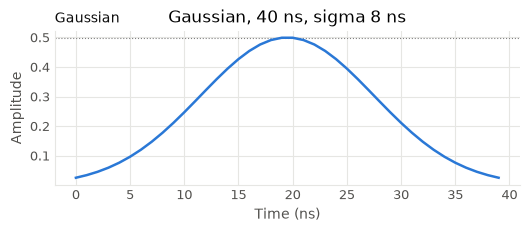

In [18]:
ax = drive_envelope.plot()
ax.set_title(f"Gaussian, {drive_envelope.get_duration()} ns, sigma {drive_envelope.sigma} ns")
ax.axhline(drive_envelope.peak_amplitude(), color="grey", linestyle=":", linewidth=0.8)
plt.show()

`target=` runs the other direction. You open the layout yourself and hand each panel to a waveform, and that is how six shapes fit in one row below.

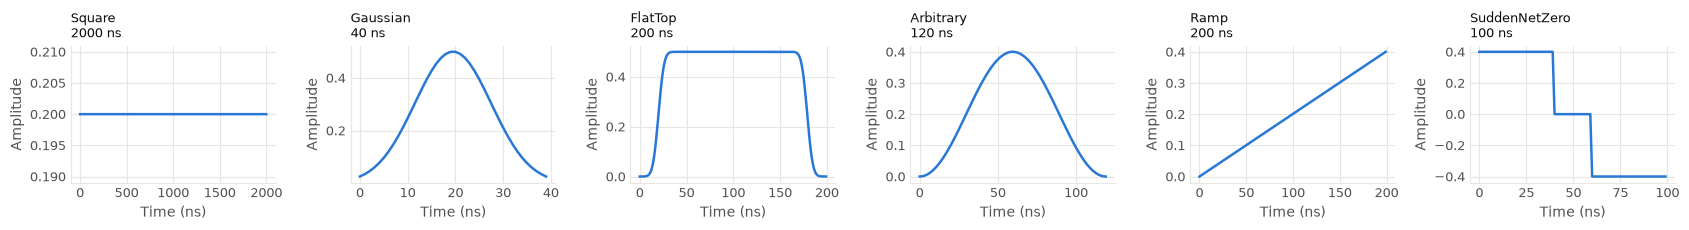

In [19]:
gallery = [
    Square(amplitude=0.2, duration=2000),  # a readout tone
    Gaussian(amplitude=0.5, duration=40, sigma=8),  # a short drive envelope
    FlatTop(amplitude=0.5, duration=200, smooth_duration=20),  # rise, hold, fall
    Arbitrary(0.4 * np.hanning(120)),  # samples from optimal control or a fit
    Ramp(from_amplitude=0.0, to_amplitude=0.4, duration=200),  # a flux excursion
    SuddenNetZero(amplitude=0.4, duration=100, b=1.0, t_phi=20),  # a two-qubit gate pulse
]

fig, panels = plt.subplots(1, len(gallery), figsize=(17, 2.4))
for panel, waveform in zip(panels, gallery, strict=True):
    waveform.plot(target=panel)  # the waveform draws itself onto the panel we opened for it
    panel.set_title(f"{type(waveform).__name__}\n{waveform.get_duration()} ns", loc="left", fontsize=9)
fig.tight_layout()
plt.show()

An IQ shape draws two panels and hands back the pair, and `target=` wants a pair too. The panels carry their own vertical scales, and that keeps the quadrature trace from being drawn as a flat line at zero. Its peak on the pi pulse is 0.0056 against 0.6192 on the in-phase path, and that small correction is what a DRAG pulse adds, with `beta` as the knob that sets it.

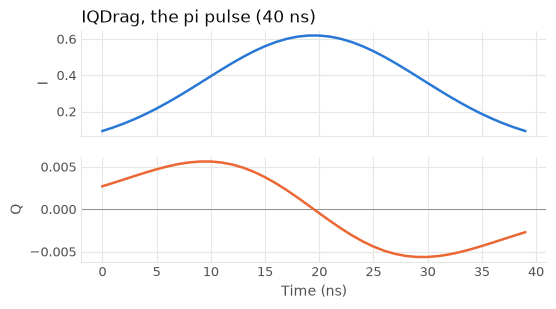

I and Q are ordinary shapes: Gaussian and GaussianDragCorrection
peak I: 0.6192
peak |Q|: 0.0056 which is the DRAG correction
IQZero leaves the quadrature silent: 0.0


In [20]:
ax_i, ax_q = pi_pulse.plot()
ax_i.set_title(f"IQDrag, the pi pulse ({pi_pulse.get_duration()} ns)", loc="left")
ax_q.axhline(0.0, color="grey", linewidth=0.6)
plt.show()

in_phase, quadrature = pi_pulse.get_I(), pi_pulse.get_Q()

print("I and Q are ordinary shapes:", type(in_phase).__name__, "and", type(quadrature).__name__)
print("peak I:", round(in_phase.peak_amplitude(), 4))
print("peak |Q|:", round(quadrature.peak_amplitude(), 4), "which is the DRAG correction")
print("IQZero leaves the quadrature silent:", IQZero(Square(0.2, 2000)).get_Q().peak_amplitude())

### Deferring the numbers

Look again at the `.qp` text of `sequence`. The amplitude 0.62 is welded into it, and that number came out of a calibration and moves as the chip drifts.

`play` and `measure` also accept a string alias instead of a waveform. The program then says which pulse it wants, and the numbers arrive later from `with_waveforms`, which returns a new program and leaves the original alone. `body.waveforms()` is how you ask a program what it still needs, and the substitution is lenient about a name it does not recognise and strict about the shape, so the channel check of section 1.4 runs again at the bind rather than back at the `play`.

A plain dict is the simplest thing to bind with. `qp.WaveformLibrary` is the same argument with a resolution order behind it, so one alias can mean a different amplitude on each qubit, and it has a text format of its own that keeps the calibration in a separate file from the experiment.

In [21]:
aliased = qp.QProgram(label="prepare_and_read", schema=schema)
aliased.play(q[0].drive, "pi")
aliased.sync([q[0].drive, q[0].readout])
aliased.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

print("still unbound:", sorted(name for name in aliased.body.waveforms() if isinstance(name, str)))

bound = aliased.with_waveforms({"pi": pi_pulse, "readout": readout_pulse, "weights": weights})
print("after binding:", statement(bound, "play"))
print("the original: ", statement(aliased, "play"))

try:
    aliased.with_waveforms({"pi": Gaussian(amplitude=A_PI, duration=40, sigma=10)})
except qp.ValidationError as exc:
    print("\nchecked at the bind:", exc)

still unbound: ['pi', 'readout', 'weights']
after binding: play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
the original:  play q[0].drive "pi"

checked at the bind: Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Gaussian). Use an IQWaveform (e.g. IQPair, IQDrag) instead.


## 1.7 The `.qp` file

You have been reading `.qp` text since the first program. `qp.dumps` writes it and `qp.loads` reads it back, and `qp.save` and `qp.load` are the same pair against a file.

Two properties are worth knowing before you commit one. Nothing is truncated, so a program holding an `Arbitrary` of 4000 samples writes 4000 samples, with no compression and no reference to an external array. And `dumps` raises `qp.SerializationError` rather than emit text it cannot read back, so a file that exists is a file that parses.

The round trip is exact, and structural equality is how you check it. One trap comes with that: `QProgram` itself defines no `__eq__`, so the comparison reads `a.body == b.body` and never `a == b`.

In [22]:
out = Path("out")
out.mkdir(exist_ok=True)
path = out / "prepare_and_read.qp"

qp.save(checked, path)
reloaded = qp.load(path)

print("wrote:", path, f"({len(path.read_text().splitlines())} lines)")
print("same structure:", reloaded.body == checked.body)
print("same text back:", qp.dumps(reloaded) == path.read_text())

wrote: out/prepare_and_read.qp (16 lines)
same structure: True
same text back: True


The consequence worth having is that the file is the experiment. A `.qp` sitting next to your data still loads, still carries the measurement names you indexed the results by, and depends on nothing about the notebook that built it. Two runs of one calibration therefore diff as two text files, and a change of one amplitude shows up as one changed line.

## 1.8 Running a program

`qp.simulate(program, model=...)` runs a program on the reference platform, the pure-Python interpreter that ships inside QProgram. It models the shape of the experiment, meaning the nesting, the repetition, and one measurement record per `measure` call. It models no pulse shapes and no timing at all, so the `wait` above changes no number.

Where the numbers come from is up to you. A measurement model is asked for one sample per shot, and `qp.MockMeasurementModel` covers most cases: `response` returns the noiseless complex point, `noise` is the gaussian sigma added per quadrature, `raw_samples` sets the length of the simulated ADC trace, and `seed` makes the run repeatable. The Basics notebook is where a model starts answering as a function of a swept variable.

The program below has no variable in it, no loop around it, and no averaging, so it is one measurement and it returns one point.

In [23]:
single = qp.QProgram(label="one_measurement", schema=schema)
single.set_frequency(q[0].readout, F_READOUT)
m_single = single.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE, MF.RAW))

model = qp.MockMeasurementModel(
    response=lambda bus, env: 0.62 + 0.18j, noise=0.02, raw_samples=64, seed=4
)
result = qp.simulate(single, model=model)

point = result.get(m_single, field=MF.IQ)
print("records in the result:", len(result))
print("the integrated point: ", f"I={float(point.sel(IQ='I')):+.4f}  Q={float(point.sel(IQ='Q')):+.4f}")
print("classified state:     ", float(result.get(m_single, field=MF.STATE)))
print("raw trace:            ", result.get(m_single, field=MF.RAW).shape, "samples by quadrature")

records in the result: 1
the integrated point:  I=+0.6070  Q=+0.1765
classified state:      0.0
raw trace:             (64, 2) samples by quadrature


`result.get(handle)` hands back an `xarray.DataArray`, and the raw trace is the one field here with an axis to plot against, because it carries one entry per time sample. `result.plot` reads the array's shape and picks the figure, so the same call that draws a line here draws a heatmap in Basics.

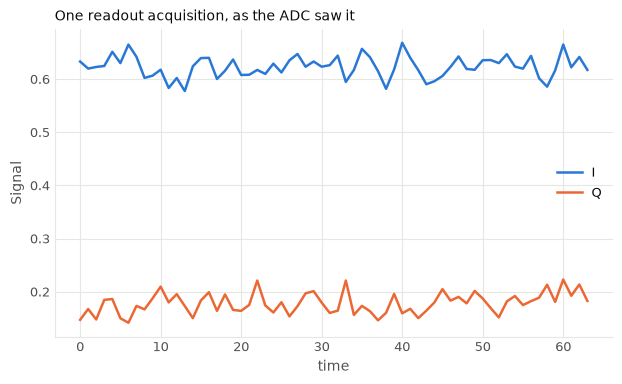

In [24]:
result.plot(m_single, field=MF.RAW, title="One readout acquisition, as the ADC saw it")
plt.show()

The integrated point has nowhere to be drawn against, and the library says so rather than guessing an axis. That message is the whole reason the Basics notebook exists: a single measurement is a number, and an experiment is a measurement repeated while something is varied.

In [25]:
try:
    result.plot(m_single, field=MF.IQ)
except qp.ValidationError as exc:
    print(exc)

Nothing to plot: an array with dims ('IQ',) is a single measured point with no dimension to plot it against. Sweep a variable, or plot the raw trace, which carries a 'time' dimension.


### 🧩 Exercise 1.1

Write one program that biases the flux line, prepares the qubit, reads it out, and survives a round trip through a file. Then let the schema catch a mistake.

1. Build a `qp.QProgram` with `label="biased_prepare_and_read"` and the `schema` already in scope.
2. `set_offset` the flux bus of `q[0]` to `0.05`, then `set_frequency` its drive bus to `F01` and its readout bus to `F_READOUT`.
3. Inside a `with program.block():`, `play` the `pi_pulse` on the drive bus and `wait` 4 ns on it.
4. `sync` the drive and readout buses by name, then `measure` the readout bus with `readout_pulse`, `weights`, and `fields=(MF.IQ, MF.STATE)`. Keep the handle.
5. Print `qp.dumps(program)`, save it to `out/exercise_1_1.qp`, load it back, and print whether the two bodies are equal.
6. Then, inside `try` and `except qp.ValidationError`, `measure` the flux bus and print the message.

Step 6 is the point. The flux line has no ADC, and the schema knows that before any hardware does.

In [26]:
exercise = qp.QProgram(label="biased_prepare_and_read", schema=schema)
exercise.set_offset(q[0].flux, 0.05)
exercise.set_frequency(q[0].drive, F01)
exercise.set_frequency(q[0].readout, F_READOUT)
with exercise.block():
    exercise.play(q[0].drive, pi_pulse)
    exercise.wait(q[0].drive, 4)
exercise.sync([q[0].drive, q[0].readout])
m_exercise = exercise.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(exercise))

exercise_path = out / "exercise_1_1.qp"
qp.save(exercise, exercise_path)
print("handle:", m_exercise.name)
print("round trips:", qp.load(exercise_path).body == exercise.body)

try:
    exercise.measure(q[0].flux, readout_pulse, weights)
except qp.ValidationError as exc:
    print("\ncaught:", exc)

#!QProgram 1.0

metadata:
  label: "biased_prepare_and_read"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  set_offset q[0].flux 0.05
  set_frequency q[0].drive 4850000000.0
  set_frequency q[0].readout 7200000000.0
  block:
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
    wait q[0].drive 4
  sync q[0].drive q[0].readout
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]

handle: q0/readout/m0
round trips: True

caught: Bus 'q0/flux' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


## Recap

- **A program is data.** Every builder call appends one typed node and sends nothing anywhere, so `qp.dumps` can print the whole tree and `program.buses` and `body.elements` can be read at any point.
- **A bus is a string.** A plain one works and is unchecked. A `BusSchema` hands back a `BusRef` that is still a string and carries `channel` and `acquires`, which reject a single-channel waveform on an IQ line, a `measure` on a bus with no ADC, and a reference borrowed from another schema.
- **Twelve operations** cover the vocabulary. `measure` and `get_parameter` hand something back and the rest return `None`. `wait` and `play` are the only two that book time, and `sync` is what lines two buses back up.
- **Waveforms are data.** `envelope()` and `get_duration()` are the contract, `area()`, `peak_amplitude()`, `spectrum()`, and `plot()` come free, and `plot()` returns the `Axes` every reference line and annotation goes on. A string alias defers the numbers to `with_waveforms`, checked at the bind.
- **`.qp` is the artifact.** `qp.loads(qp.dumps(p)).body == p.body`, so a diff of two files is a diff of two calibrations.
- **`qp.simulate` runs it.** One measurement with no loop around it returns one point, one classified state, and one raw trace, and only the trace has an axis to be drawn against.

## Next

**Basics.** A variable is the hole in a program where a knob goes, a sweep source says how that knob moves, and `average(shots)` repeats the whole thing. Those three turn the single sequence you just ran into an experiment, and the arrays that come back are labeled with the names you declared.